#**Segmentation Stratégique Client par CLV et Risque d'Attrition — Secteur Télécom (Bénin)**
Ce projet combine une lecture du présent (profil et valeur actuelle des clients) et une projection du futur (valeur vie client et risque de départ), sur un dataset simulé représentatif du marché télécom béninois (1M clients), scindé en deux sous-ensembles distincts : un dataset Historique (800K clients, avec résultat de churn connu) utilisé pour construire et valider le modèle, et un dataset Production (200K clients) sur lequel le modèle est ensuite appliqué pour scorer, calculer la CLV et segmenter — reproduisant la logique réelle d'un déploiement en production, où le modèle est entraîné sur des données passées puis utilisé sur des clients dont l'issue future est encore inconnue.
##**Objectifs :**

Comprendre la base client actuelle (EDA descriptif, sur l'historique)

Construire les features nécessaires (tendance ARPU, etc.)

Modéliser le risque de rétention (classification comparée sur 3 modèles + SHAP, entraînée sur l'historique)

Calibrer les probabilités pour un usage financier fiable

Appliquer le modèle au dataset Production pour calculer la CLV (ARPU × probabilité cumulée de rétention)

Segmenter les clients du dataset Production (matrice CLV × risque)

Restituer via dashboard Power BI (vue présent / vue futur)


##**1-Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from google.colab import drive
drive.mount('/content/drive')
data=pd.read_csv('/content/drive/MyDrive/Projet_Telecom /telecom_benin_historique.csv')
data.head()

Mounted at /content/drive


,customer_id,departement,zone,age,genre,anciennete_mois,arpu_mensuel_fcfa,usage_data_gb,minutes_voix,sms_mensuel,...,montant_recharge_moyen_fcfa,jours_depuis_derniere_recharge,canal_recharge_principal,arpu_m1_fcfa,arpu_m2_fcfa,arpu_m3_fcfa,arpu_m4_fcfa,arpu_m5_fcfa,arpu_m6_fcfa,churn
0,BJ893321,Mono,Rural,65,M,17,2198.0,2.93,53.0,7,...,1784.0,76,App mobile,2296.0,2356.0,2267.0,2502.0,2411.0,2413.0,1
1,BJ387632,Littoral,Urbain,56,F,18,2839.0,1.42,142.0,12,...,2797.0,2,Agent physique,3004.0,3185.0,3039.0,2976.0,2995.0,2934.0,0
2,BJ905210,Zou,Rural,57,F,7,2849.0,3.39,55.0,5,...,2418.0,15,Agent physique,2765.0,2694.0,2668.0,2510.0,2398.0,2255.0,0
3,BJ856948,Mono,Urbain,25,M,15,9639.0,22.93,251.0,39,...,11889.0,3,USSD,9492.0,8477.0,7612.0,6807.0,7038.0,7056.0,0
4,BJ927080,Ouémé,Urbain,64,F,20,3511.0,5.46,84.0,15,...,3104.0,40,USSD,3341.0,3421.0,3313.0,3505.0,3714.0,3924.0,0


## Phase 1 — Exploration des données (EDA)

### 1.1 Qualité des données
Vérification des valeurs manquantes et des doublons.

In [ ]:
data.shape

(800000, 25)

In [ ]:
data.dtypes

,0
customer_id,object
departement,object
zone,object
age,int64
genre,object
anciennete_mois,int64
arpu_mensuel_fcfa,float64
usage_data_gb,float64
minutes_voix,float64
sms_mensuel,int64


In [ ]:
data.isnull().sum()

,0
customer_id,0
departement,0
zone,0
age,0
genre,0
anciennete_mois,0
arpu_mensuel_fcfa,0
usage_data_gb,0
minutes_voix,0
sms_mensuel,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['customer_id'].duplicated().sum()

np.int64(0)

### 1.2 Statistiques descriptives
Vue d'ensemble des variables numériques et catégorielles.

In [ ]:
data.describe()

,age,anciennete_mois,arpu_mensuel_fcfa,usage_data_gb,minutes_voix,sms_mensuel,nb_transactions_mm,qualite_reseau_score,appels_service_client_3m,reclamations_3m,montant_recharge_moyen_fcfa,jours_depuis_derniere_recharge,arpu_m1_fcfa,arpu_m2_fcfa,arpu_m3_fcfa,arpu_m4_fcfa,arpu_m5_fcfa,arpu_m6_fcfa,churn
count,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.0
mean,42.502533,21.518706,3301.983261,3.955325,66.132626,10.970736,3.871400,6.600856,1.364205,0.340749,3302.275556,13.528334,3296.353317,3291.188639,3286.491910,3282.327071,3278.922625,3276.443556,0.2
std,15.585152,14.828963,2720.233188,4.838943,81.487843,9.463136,3.480746,1.690348,1.345599,0.566195,2820.004387,14.004197,2716.131511,2711.800962,2710.302349,2710.142177,2711.168280,2714.650066,0.4
min,16.000000,1.000000,300.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,210.000000,0.000000,245.000000,223.000000,207.000000,200.000000,200.000000,200.000000,0.0
25%,29.000000,11.000000,1394.000000,1.040000,17.000000,4.000000,0.000000,5.400000,0.000000,0.000000,1352.000000,4.000000,1393.000000,1391.000000,1390.000000,1388.000000,1386.000000,1383.000000,0.0
50%,43.000000,18.000000,2545.000000,2.360000,39.000000,8.000000,4.000000,6.600000,1.000000,0.000000,2499.000000,9.000000,2543.000000,2540.000000,2536.000000,2534.000000,2532.000000,2526.000000,0.0
75%,56.000000,29.000000,4378.000000,4.980000,83.000000,15.000000,7.000000,7.800000,2.000000,1.000000,4360.000000,19.000000,4367.000000,4359.000000,4351.000000,4348.000000,4345.000000,4344.000000,0.0
max,69.000000,120.000000,32705.000000,60.000000,1900.000000,78.000000,20.000000,10.000000,11.000000,3.000000,37709.000000,180.000000,31168.000000,32725.000000,33586.000000,35262.000000,37487.000000,38333.000000,1.0


In [ ]:
data.describe(include=["object"])

,customer_id,departement,zone,genre,canal_recharge_principal
count,800000,800000,800000,800000,800000
unique,800000,12,2,2,3
top,BJ443415,Atlantique,Rural,M,Agent physique
freq,1,127809,415944,416596,354330


### 1.3 Analyse du churn
Répartition de la variable cible et lien avec les principales variables catégorielles et numériques.

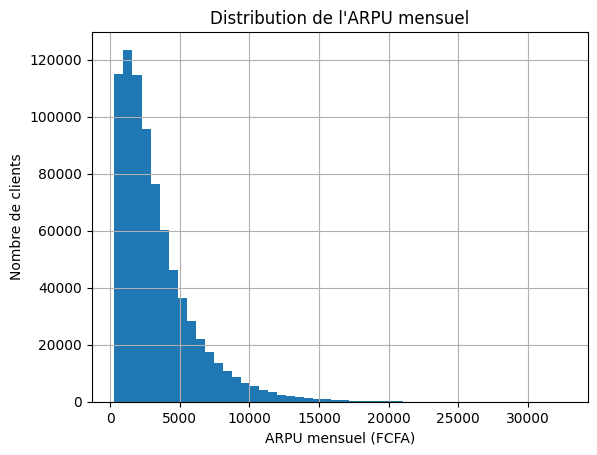

In [ ]:
data["arpu_mensuel_fcfa"].hist(bins=50)
plt.xlabel('ARPU mensuel (FCFA)')
plt.ylabel('Nombre de clients')
plt.title('Distribution de l\'ARPU mensuel')
plt.show()

In [ ]:
data['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.8
1,0.2


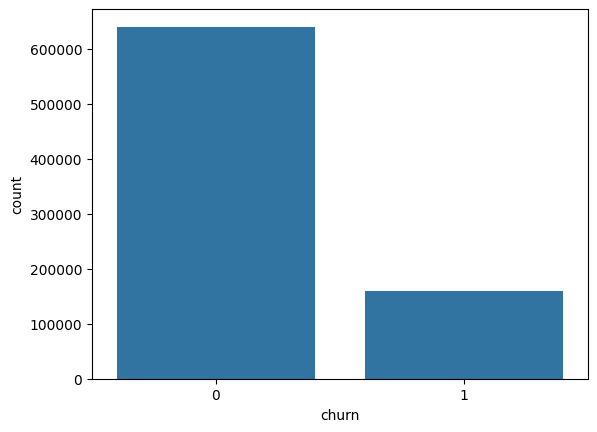

In [ ]:
sns.countplot(x='churn', data=data)
plt.show()

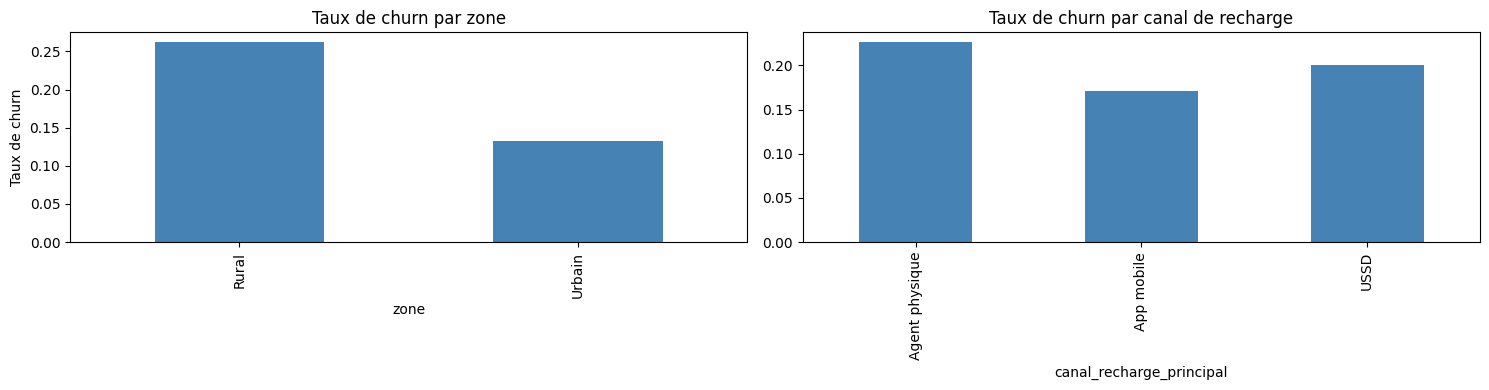

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

data.groupby('zone')['churn'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Taux de churn par zone')
axes[0].set_ylabel('Taux de churn')



data.groupby('canal_recharge_principal')['churn'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Taux de churn par canal de recharge')

plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(data['canal_recharge_principal'], data['zone'], normalize='index')

zone,Rural,Urbain
canal_recharge_principal,,
Agent physique,0.717808,0.282192
App mobile,0.304867,0.695133
USSD,0.517984,0.482016


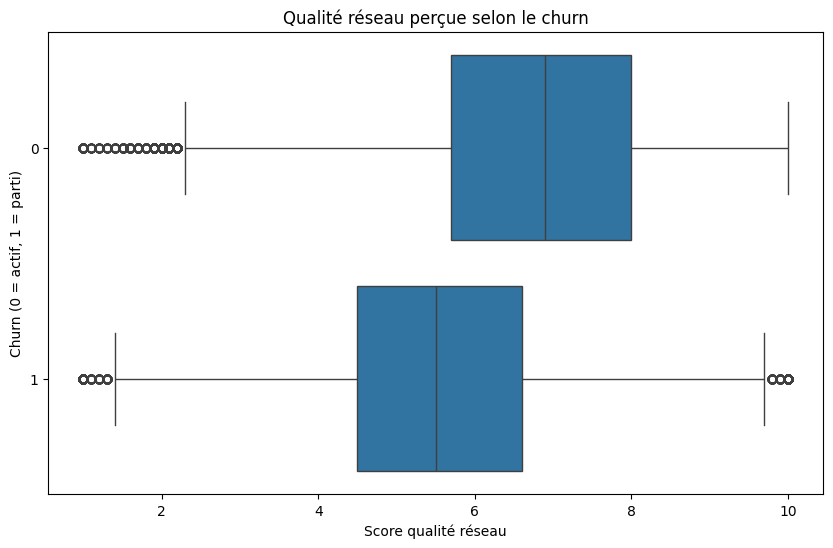

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='qualite_reseau_score', y='churn', orient='h')
plt.xlabel('Score qualité réseau')
plt.ylabel('Churn (0 = actif, 1 = parti)')
plt.title('Qualité réseau perçue selon le churn')
plt.show()

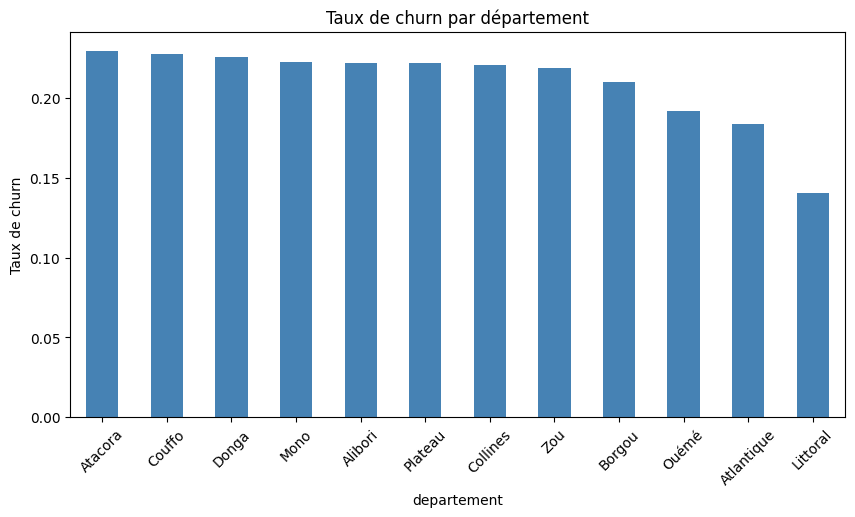

In [ ]:
plt.figure(figsize=(10,5))
data.groupby('departement')['churn'].mean().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.ylabel('Taux de churn')
plt.title('Taux de churn par département')
plt.xticks(rotation=45)
plt.show()

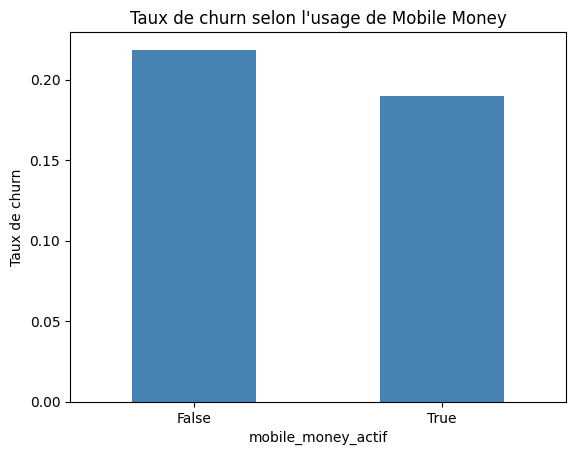

In [ ]:
data.groupby('mobile_money_actif')['churn'].mean().plot(kind='bar', color='steelblue')
plt.ylabel('Taux de churn')
plt.title('Taux de churn selon l\'usage de Mobile Money')
plt.xticks(rotation=0)
plt.show()

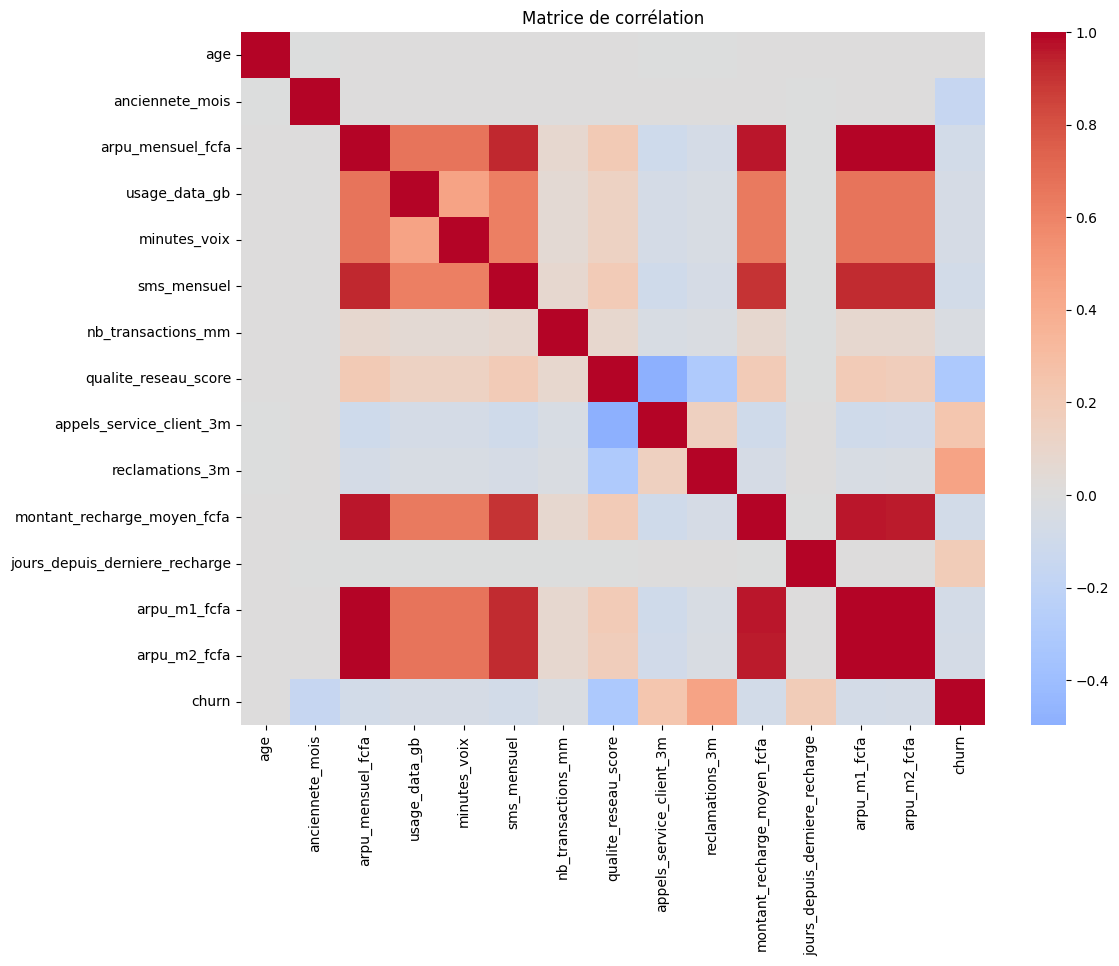

In [ ]:


numeric_cols = ['age', 'anciennete_mois', 'arpu_mensuel_fcfa', 'usage_data_gb',
                 'minutes_voix', 'sms_mensuel', 'nb_transactions_mm',
                 'qualite_reseau_score', 'appels_service_client_3m', 'reclamations_3m',
                 'montant_recharge_moyen_fcfa', 'jours_depuis_derniere_recharge',
                 'arpu_m1_fcfa', 'arpu_m2_fcfa', 'churn']

corr = data[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.show()

### 1.4 Analyse Pareto — concentration du revenu
Quelle part du chiffre d'affaires est portée par les clients à forte valeur ?

In [ ]:
n_top = int(len(data) * 0.20)  # nombre de clients dans les 20% les plus gros
top_20_pct = data.sort_values('arpu_mensuel_fcfa', ascending=False).head(n_top)

pct_revenu = top_20_pct['arpu_mensuel_fcfa'].sum() / data['arpu_mensuel_fcfa'].sum() * 100
print(f"Les 20% de clients les plus gros génèrent {pct_revenu:.1f}% du revenu total")

Les 20% de clients les plus gros génèrent 46.4% du revenu total


## Synthèse — Phase 1 : Exploration des données (EDA)

### Qualité des données
Dataset de 1 000 000 clients, 21 variables, sans valeurs manquantes ni doublons (customer_id unique).
### Statistiques descriptives
L'ARPU mensuel (moyenne 3724 FCFA, médiane 2704 FCFA) présente une distribution asymétrique à droite : une majorité de clients à faible/moyen revenu, et une minorité de clients à forte valeur qui tirent la moyenne vers le haut; signal cohérent avec une logique de concentration du revenu typique du secteur télécom.

### Analyse du churn
Taux de churn global : 20%. Plusieurs variables montrent une association avec le churn :
- **Qualité réseau perçue** et **réclamations** : corrélées au churn dans le sens attendu (moins bonne qualité / plus de réclamations → plus de churn)
- **Zone, canal de recharge, département, Mobile Money** : montrent des écarts de taux de churn, mais l'analyse croisée révèle qu'ils **ne sont pas des facteurs indépendants**; ils reflètent tous, à des degrés divers, la même variable structurante sous-jacente : **la disparité urbain/rural**. Le département et le canal de recharge agissent ici comme des variables de confusion plutôt que des causes propres du churn.

### Analyse Pareto
Les 20% de clients à plus forte valeur génèrent **46,4% du revenu total**; une concentration suffisante pour justifier une approche de segmentation différenciée plutôt qu'une stratégie de rétention uniforme.

### Limite à retenir
Ce dataset est **synthétique**, faute d'accès à des données opérateur réelles (confidentielles). Les ordres de grandeur (ARPU, taux de Mobile Money, disparité urbain/rural) sont construits pour être plausibles au regard du marché télécom béninois, mais les valeurs précises et corrélations restent des hypothèses de modélisation, non des données vérifiées.

---

**Prochaine étape (Phase 2 — Feature engineering)** : construction de variables dérivées à partir des données brutes, notamment la tendance d'ARPU (`arpu_mensuel_fcfa`, `arpu_m1_fcfa`, `arpu_m2_fcfa`), en tenant compte de la multicolinéarité identifiée entre les variables liées à l'ARPU.

## Phase 2 — Feature Engineering
### 2.1 Construction de la tendance ARPU

In [ ]:
data['variation_arpu_pct'] = (data['arpu_mensuel_fcfa'] - data['arpu_m6_fcfa']) / data['arpu_m6_fcfa'] * 100

In [ ]:
def categoriser_tendance(variation):
    if variation <= -10:
        return 'Baisse'
    elif variation >= 10:
        return 'Hausse'
    else:
        return 'Stable'

data['tendance_arpu'] = data['variation_arpu_pct'].apply(categoriser_tendance)

In [ ]:
data['tendance_arpu'].value_counts(normalize=True)

,proportion
tendance_arpu,
Stable,0.491733
Hausse,0.285234
Baisse,0.223034


In [ ]:
pd.crosstab(data['tendance_arpu'], data['churn'], normalize='columns')

churn,0,1
tendance_arpu,,
Baisse,0.169395,0.437588
Hausse,0.326494,0.120194
Stable,0.504111,0.442219



La tendance ARPU (calculée sur un écart de 6 mois) montre une nette discrimination entre clients actifs et churners :
- Clients actifs : 17% Baisse / 50% Stable / 33% Hausse
- Clients churnés : 44% Baisse / 44% Stable / 12% Hausse

Cette variable sera intégrée au modèle de rétention en Phase 3.

### 2.2 Encodage des variables catégorielles

Transformation des variables textuelles en variables numériques pour les rendre exploitables par les modèles :
- **One-Hot Encoding** pour les variables nominales sans ordre logique (zone, genre, département, canal de recharge)
- **Encodage ordinal** pour `tendance_arpu`, qui possède un ordre naturel (Baisse < Stable < Hausse)

In [ ]:
# One-Hot pour les variables nominales (sans ordre)
data_encoded = pd.get_dummies(data, columns=['zone', 'genre', 'departement', 'canal_recharge_principal'],
                                drop_first=True)

# Encodage ordinal pour tendance_arpu (qui a un ordre logique)
ordre_tendance = {'Baisse': 0, 'Stable': 1, 'Hausse': 2}
data_encoded['tendance_arpu_encoded'] = data['tendance_arpu'].map(ordre_tendance)

In [ ]:
data_encoded.shape

(800000, 39)

In [ ]:
data_encoded.columns.tolist()

['customer_id',
 'age',
 'anciennete_mois',
 'arpu_mensuel_fcfa',
 'usage_data_gb',
 'minutes_voix',
 'sms_mensuel',
 'mobile_money_actif',
 'nb_transactions_mm',
 'qualite_reseau_score',
 'appels_service_client_3m',
 'reclamations_3m',
 'montant_recharge_moyen_fcfa',
 'jours_depuis_derniere_recharge',
 'arpu_m1_fcfa',
 'arpu_m2_fcfa',
 'arpu_m3_fcfa',
 'arpu_m4_fcfa',
 'arpu_m5_fcfa',
 'arpu_m6_fcfa',
 'churn',
 'variation_arpu_pct',
 'tendance_arpu',
 'zone_Urbain',
 'genre_M',
 'departement_Atacora',
 'departement_Atlantique',
 'departement_Borgou',
 'departement_Collines',
 'departement_Couffo',
 'departement_Donga',
 'departement_Littoral',
 'departement_Mono',
 'departement_Ouémé',
 'departement_Plateau',
 'departement_Zou',
 'canal_recharge_principal_App mobile',
 'canal_recharge_principal_USSD',
 'tendance_arpu_encoded']

In [ ]:
data_encoded = data_encoded.drop(columns=['tendance_arpu'])

In [ ]:
data_encoded.dtypes

,0
customer_id,object
age,int64
anciennete_mois,int64
arpu_mensuel_fcfa,float64
usage_data_gb,float64
minutes_voix,float64
sms_mensuel,int64
mobile_money_actif,bool
nb_transactions_mm,int64
qualite_reseau_score,float64


## Phase 3 — Modélisation

### 3.1 Split train/test

In [ ]:
from sklearn.model_selection import train_test_split

X = data_encoded.drop(columns=['customer_id', 'churn'])
y = data_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Taux de churn train:", y_train.mean().round(3))
print("Taux de churn test:", y_test.mean().round(3))

Train: (640000, 36) Test: (160000, 36)
Taux de churn train: 0.2
Taux de churn test: 0.2


### 3.2 Normalisation

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.3 Gestion du déséquilibre des classes

Le churn représente 20% des observations (déséquilibre modéré). Plutôt que de rééchantillonner les données (SMOTE), on utilise une pondération des classes, intégrée directement dans les hyperparamètres de chaque modèle : `class_weight='balanced'` pour la régression logistique et Random Forest, `scale_pos_weight` (calculé automatiquement) pour XGBoost.

### 3.4 Échantillon pour la recherche d'hyperparamètres + grilles de paramètres

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
# --- Échantillon stratifié pour la recherche d'hyperparamètres (à partir du train uniquement) ---
X_sample, _, y_sample, _ = train_test_split(
    X_train_scaled, y_train, train_size=120_000, stratify=y_train, random_state=42
)
print("Echantillon:", X_sample.shape, "Taux de churn:", y_sample.mean().round(3))

Echantillon: (120000, 36) Taux de churn: 0.2


In [ ]:
# --- Grilles de paramètres (scale_pos_weight calculé directement ici, pas de variable à part) ---
log_reg_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': ['balanced']
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'class_weight': ['balanced']
}

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'scale_pos_weight': [(y_sample == 0).sum() / (y_sample == 1).sum()]
}

### 3.5 Recherche d'hyperparamètres (RandomizedSearchCV) sur l'échantillon

In [ ]:
# --- Régression Logistique ---
log_reg_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=log_reg_param_grid,
    n_iter=4, scoring='recall', cv=5, random_state=42, n_jobs=-1, verbose=1
)
log_reg_search.fit(X_sample, y_sample)
print("Meilleurs params LogReg:", log_reg_search.best_params_)
print("Meilleur recall LogReg:", log_reg_search.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Meilleurs params LogReg: {'class_weight': 'balanced', 'C': 0.01}
Meilleur recall LogReg: 0.7714583333333334


In [ ]:
# --- Random Forest ---
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=8, scoring='recall', cv=5, random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_sample, y_sample)
print("Meilleurs params RF:", rf_search.best_params_)
print("Meilleur recall RF:", rf_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs params RF: {'n_estimators': 300, 'max_depth': 5, 'class_weight': 'balanced'}
Meilleur recall RF: 0.7465833333333334


In [ ]:
# --- XGBoost ---
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=8, scoring='recall', cv=5, random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_sample, y_sample)
print("Meilleurs params XGB:", xgb_search.best_params_)
print("Meilleur recall XGB:", xgb_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs params XGB: {'scale_pos_weight': np.float64(4.0), 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Meilleur recall XGB: 0.788


### 3.6 Entraînement du modèle final (XGBoost) sur le train complet

In [ ]:
best_xgb_params = xgb_search.best_params_

final_model = XGBClassifier(
    n_estimators=best_xgb_params['n_estimators'],
    max_depth=best_xgb_params['max_depth'],
    learning_rate=best_xgb_params['learning_rate'],
    scale_pos_weight=best_xgb_params['scale_pos_weight'],
    eval_metric='logloss',
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

### 3.7 Évaluation sur le test

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = final_model.predict(X_test_scaled)
y_pred_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba).round(3))
print("\nMatrice de confusion:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.77      0.85    128000
           1       0.47      0.79      0.59     32000

    accuracy                           0.78    160000
   macro avg       0.70      0.78      0.72    160000
weighted avg       0.84      0.78      0.80    160000

AUC-ROC: 0.866

Matrice de confusion:
[[98969 29031]
 [ 6656 25344]]


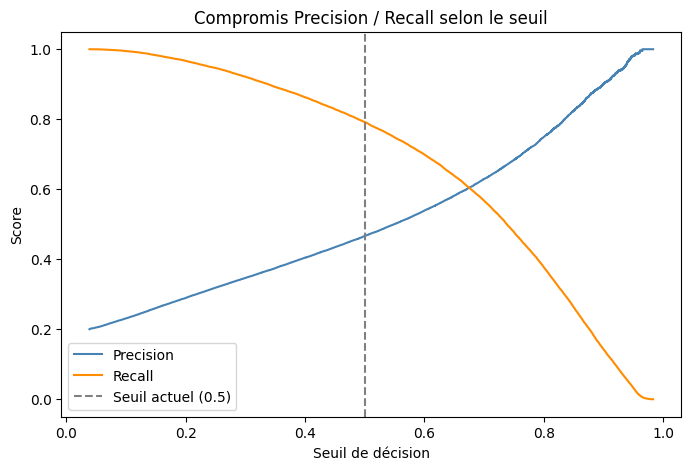

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall[:-1], label='Recall', color='darkorange')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Seuil actuel (0.5)')
plt.xlabel('Seuil de décision')
plt.ylabel('Score')
plt.title('Compromis Precision / Recall selon le seuil')
plt.legend()
plt.show()

### 3.8 Interprétabilité du modèle (SHAP)

In [ ]:
import shap

# SHAP peut être lent sur 800K lignes -> on utilise un échantillon pour l'analyse
X_shap_sample = X_test_scaled[:5000]  # ou un sample aléatoire équivalent

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap_sample)

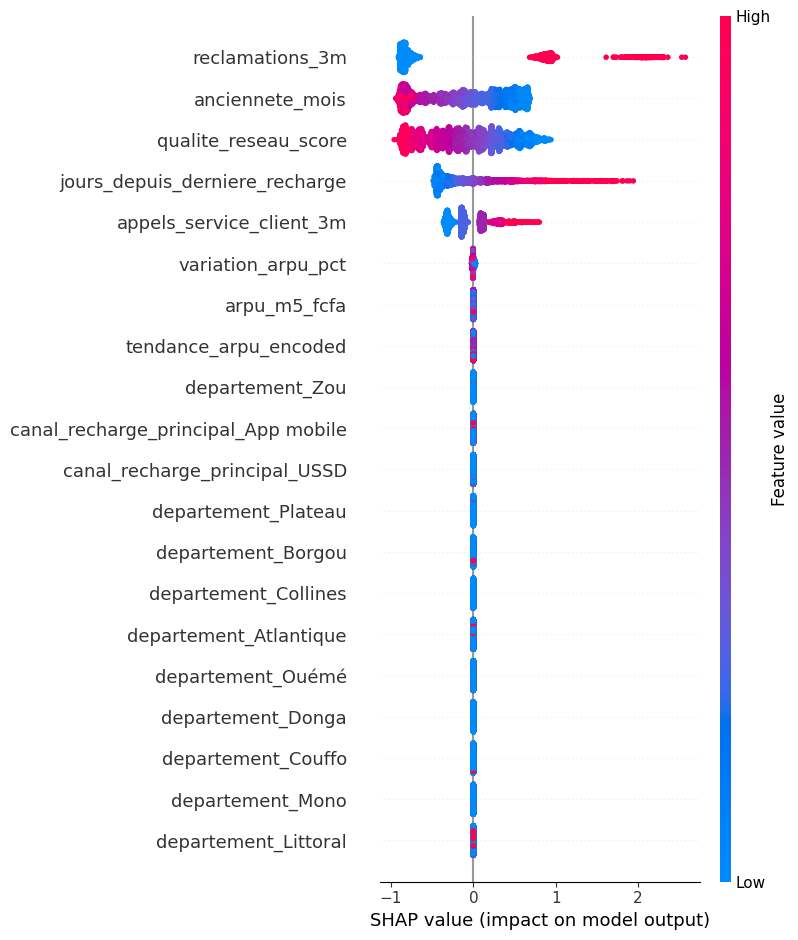

In [ ]:
shap.summary_plot(shap_values, X_shap_sample, feature_names=X.columns)

### 3.9 Calibration des probabilités (sur le dataset Historique)

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()

calibrated_model = CalibratedClassifierCV(
    estimator=XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight_value, eval_metric='logloss', random_state=42
    ),
    method='sigmoid', cv=5
)

calibrated_model.fit(X_train_scaled, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=True,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=3,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=100, n_jobs=None,
                                               num_parallel_tree=None, ...))

## Synthèse — Phase 3 : Modélisation

### Comparaison des modèles (entraînement et validation sur le dataset Historique)
Trois modèles ont été comparés via RandomizedSearchCV (recherche d'hyperparamètres sur échantillon de 120K clients issus de l'historique, validation croisée à 5 plis, optimisation sur le recall) :

| Modèle | Recall (validation croisée) |
|---|---|
| Régression Logistique | 77,1% |
| Random Forest | 74,7% |
| **XGBoost (retenu)** | **78,8%** |

XGBoost obtient le meilleur recall, avec un gain modeste par rapport à la régression logistique — cohérent avec l'observation initiale que le signal capté est en grande partie linéaire.

## Phase 4 — Application du modèle au dataset Production

### 4.0 Chargement du dataset Production

In [ ]:
data_production=pd.read_csv('/content/drive/MyDrive/Projet_Telecom /telecom_benin_production.csv')
# On met de côté le vrai churn -- jamais utilisé pour le scoring, la CLV ou la segmentation
vrai_churn_production = data_production['churn'].copy()
data_production = data_production.drop(columns=['churn'])

print(data_production.shape)

(200000, 24)


### 4.1 Feature engineering (identique à celui appliqué sur l'historique)

In [ ]:
# Tendance ARPU
data_production['variation_arpu_pct'] = (data_production['arpu_mensuel_fcfa'] - data_production['arpu_m6_fcfa']) / data_production['arpu_m6_fcfa'] * 100

def categoriser_tendance(variation):
    if variation <= -10:
        return 'Baisse'
    elif variation >= 10:
        return 'Hausse'
    else:
        return 'Stable'

data_production['tendance_arpu'] = data_production['variation_arpu_pct'].apply(categoriser_tendance)

# Encodage
data_production_encoded = pd.get_dummies(data_production, columns=['zone', 'genre', 'departement', 'canal_recharge_principal'], drop_first=True)
ordre_tendance = {'Baisse': 0, 'Stable': 1, 'Hausse': 2}
data_production_encoded['tendance_arpu_encoded'] = data_production['tendance_arpu'].map(ordre_tendance)
data_production_encoded = data_production_encoded.drop(columns=['tendance_arpu'])

print(data_production_encoded.shape)

(200000, 37)


### 4.2 Normalisation et scoring (avec le scaler et les modèles entraînés sur l'historique)

In [ ]:
X_production = data_production_encoded.drop(columns=['customer_id'])

print(list(X.columns) == list(X_production.columns))  # doit afficher True

X_production_scaled = scaler.transform(X_production)  # transform seul, jamais fit ici

proba_churn_production = final_model.predict_proba(X_production_scaled)[:, 1]
proba_churn_production_calibree = calibrated_model.predict_proba(X_production_scaled)[:, 1]

print("Moyenne proba brute:", proba_churn_production.mean().round(3))
print("Moyenne proba calibrée:", proba_churn_production_calibree.mean().round(3))

True
Moyenne proba brute: 0.392
Moyenne proba calibrée: 0.2


### 4.3 Calcul de la CLV (horizon 12 mois)

In [ ]:
proba_retention_production = 1 - proba_churn_production_calibree
horizon_mois = 12
arpu_actuel_production = data_production['arpu_mensuel_fcfa'].values

clv_production = np.zeros(len(proba_retention_production))
for t in range(1, horizon_mois + 1):
    clv_production += arpu_actuel_production * (proba_retention_production ** t)

resultats_production = pd.DataFrame({
    'customer_id': data_production['customer_id'].values,
    'arpu_actuel': arpu_actuel_production,
    'proba_churn': proba_churn_production,
    'proba_churn_calibree': proba_churn_production_calibree,
    'clv_12_mois_calibree': clv_production
})

resultats_production.describe()

,arpu_actuel,proba_churn,proba_churn_calibree,clv_12_mois_calibree
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,3304.569625,0.391623,0.200288,21825.326114
std,2718.316012,0.266715,0.227334,25601.336036
min,300.000000,0.038937,0.014686,67.045478
25%,1400.000000,0.153242,0.029161,3822.748924
50%,2555.000000,0.329464,0.080251,12871.165344
75%,4381.000000,0.613202,0.324786,30442.048306
max,40641.000000,0.983726,0.819729,392427.400926


## Synthèse — Phase 4 : Scoring et calcul de la CLV (dataset Production)

Le modèle entraîné et calibré sur le dataset Historique est appliqué au dataset Production (200 000 clients), jamais vu pendant l'entraînement ni la validation — reproduisant la logique d'un déploiement réel où le modèle score des clients dont l'issue future est encore inconnue.

La probabilité de churn brute du modèle de classification reste gonflée (moyenne 39,2%), confirmant que ce biais de calibration se transmet bien au nouveau jeu de clients. Après calibration (`CalibratedClassifierCV`), la moyenne des probabilités redescend à 20%, cohérente avec le taux de churn réel du dataset Production (mis de côté, non utilisé dans le calcul).

La CLV est calculée sur un horizon de 12 mois à partir des probabilités calibrées : CLV moyenne de **21 825 FCFA** par client, avec une forte variabilité (de quelques dizaines à plus de 392 000 FCFA) — cohérent avec la concentration de valeur identifiée en EDA.

## Phase 5 — Segmentation (dataset Production)

### 5.1 Construction de la matrice à 4 quadrants

In [ ]:
mediane_clv = resultats_production['clv_12_mois_calibree'].median()
mediane_risque = resultats_production['proba_churn_calibree'].median()
print("Médiane CLV:", round(mediane_clv, 0))
print("Médiane risque de churn:", round(mediane_risque, 3))

Médiane CLV: 12871.0
Médiane risque de churn: 0.08


In [ ]:
def segmenter(row):
    valeur_haute = row['clv_12_mois_calibree'] >= mediane_clv
    risque_haut = row['proba_churn_calibree'] >= mediane_risque

    if valeur_haute and risque_haut:
        return 'Haute valeur - Haut risque'
    elif valeur_haute and not risque_haut:
        return 'Haute valeur - Faible risque'
    elif not valeur_haute and risque_haut:
        return 'Faible valeur - Haut risque'
    else:
        return 'Faible valeur - Faible risque'

resultats_production['segment'] = resultats_production.apply(segmenter, axis=1)

resultats_production['segment'].value_counts()

,count
segment,
Faible valeur - Haut risque,78912
Haute valeur - Faible risque,78912
Haute valeur - Haut risque,21088
Faible valeur - Faible risque,21088


### 5.2 Revenu par segment

In [ ]:
resultats_production.groupby('segment')['arpu_actuel'].sum() / resultats_production['arpu_actuel'].sum() * 100

,arpu_actuel
segment,
Faible valeur - Faible risque,2.693252
Faible valeur - Haut risque,28.117812
Haute valeur - Faible risque,51.794155
Haute valeur - Haut risque,17.394781


## Synthèse — Phase 5 : Segmentation (dataset Production)

La segmentation croise CLV prédite (12 mois) et probabilité de churn calibrée sur les 200 000 clients du dataset Production, avec un seuil médian sur chaque axe. Comme attendu, la matrice n'est pas équilibrée à 25% par quadrant, le risque de churn étant une composante directe du calcul de la CLV.

| Segment | % clients | % revenu total |
|---|---|---|
| Haute valeur - Faible risque | 39,4% | 51,8% |
| Faible valeur - Haut risque | 39,4% | 28,1% |
| Haute valeur - Haut risque | 10,6% | 17,4% |
| Faible valeur - Faible risque | 10,6% | 2,7% |

**Recommandation** : concentrer les actions de rétention prioritaires sur le segment "Haute valeur - Haut risque" (~21 200 clients, 17,4% du revenu total) — un effort ciblé sur une fraction restreinte de la base, avec un impact financier disproportionné.

## Phase 6 — Export des données pour Power BI (dataset Production)

In [ ]:
infos_descriptives = data_production[[
    'customer_id', 'departement', 'zone', 'age', 'genre', 'anciennete_mois',
    'qualite_reseau_score', 'reclamations_3m', 'appels_service_client_3m',
    'mobile_money_actif', 'canal_recharge_principal', 'tendance_arpu',
    'jours_depuis_derniere_recharge'
]]

export_powerbi = infos_descriptives.merge(resultats_production, on='customer_id')

print(export_powerbi.shape)
export_powerbi.head()

(200000, 18)


,customer_id,departement,zone,age,genre,anciennete_mois,qualite_reseau_score,reclamations_3m,appels_service_client_3m,mobile_money_actif,canal_recharge_principal,tendance_arpu,jours_depuis_derniere_recharge,arpu_actuel,proba_churn,proba_churn_calibree,clv_12_mois_calibree,segment
0,BJ664768,Zou,Rural,50,M,7,6.0,1,2,True,Agent physique,Hausse,16,2239.0,0.808547,0.613302,1411.713671,Faible valeur - Haut risque
1,BJ147545,Couffo,Rural,40,F,13,5.6,0,0,True,App mobile,Stable,7,2184.0,0.283151,0.063705,17529.541964,Haute valeur - Faible risque
2,BJ272288,Littoral,Urbain,31,F,44,6.3,0,1,True,USSD,Stable,8,3404.0,0.095510,0.020652,35759.164227,Haute valeur - Faible risque
3,BJ836659,Alibori,Rural,42,M,5,6.5,1,2,False,Agent physique,Stable,21,1936.0,0.831574,0.639792,1089.976746,Faible valeur - Haut risque
4,BJ705725,Atlantique,Urbain,19,F,19,9.4,0,0,True,App mobile,Hausse,37,5670.0,0.244260,0.046789,50514.833855,Haute valeur - Faible risque


In [ ]:
export_powerbi.to_csv('clients_clv_segmentation.csv', index=False)

from google.colab import files
files.download('clients_clv_segmentation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>